## Objective
* The goal of this data analysis project using sql would be to identify opportunities to increase the occupancy rate on low-performing flights, which can ultimately
lead to increased profitability for the airline.

### Importing Libraries

In [6]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Database Connection

In [7]:
connection = sqlite3.connect('/travel.sqlite')
cursor = connection.cursor()

In [8]:
cursor.execute("""select name from sqlite_master where type = 'table';""")
print('list of tables present in the database')
table_list = [table[0] for table in cursor.fetchall()]
table_list

list of tables present in the database


['aircrafts_data',
 'airports_data',
 'boarding_passes',
 'bookings',
 'flights',
 'seats',
 'ticket_flights',
 'tickets']

### Data Exploration

In [9]:
aircrafts_data = pd.read_sql_query("select * from aircrafts_data", connection)

In [10]:
aircrafts_data

,aircraft_code,model,range
0,773,"{""en"": ""Boeing 777-300"", ""ru"": ""Боинг 777-300""}",11100
1,763,"{""en"": ""Boeing 767-300"", ""ru"": ""Боинг 767-300""}",7900
2,SU9,"{""en"": ""Sukhoi Superjet-100"", ""ru"": ""Сухой Суп...",3000
3,320,"{""en"": ""Airbus A320-200"", ""ru"": ""Аэробус A320-...",5700
4,321,"{""en"": ""Airbus A321-200"", ""ru"": ""Аэробус A321-...",5600
5,319,"{""en"": ""Airbus A319-100"", ""ru"": ""Аэробус A319-...",6700
6,733,"{""en"": ""Boeing 737-300"", ""ru"": ""Боинг 737-300""}",4200
7,CN1,"{""en"": ""Cessna 208 Caravan"", ""ru"": ""Сессна 208...",1200
8,CR2,"{""en"": ""Bombardier CRJ-200"", ""ru"": ""Бомбардье ...",2700


In [11]:
airports_data = pd.read_sql_query("select * from airports_data", connection)
airports_data

,airport_code,airport_name,city,coordinates,timezone
0,YKS,"{""en"": ""Yakutsk Airport"", ""ru"": ""Якутск""}","{""en"": ""Yakutsk"", ""ru"": ""Якутск""}","(129.77099609375,62.0932998657226562)",Asia/Yakutsk
1,MJZ,"{""en"": ""Mirny Airport"", ""ru"": ""Мирный""}","{""en"": ""Mirnyj"", ""ru"": ""Мирный""}","(114.03900146484375,62.534698486328125)",Asia/Yakutsk
2,KHV,"{""en"": ""Khabarovsk-Novy Airport"", ""ru"": ""Хабар...","{""en"": ""Khabarovsk"", ""ru"": ""Хабаровск""}","(135.18800354004,48.5279998779300001)",Asia/Vladivostok
3,PKC,"{""en"": ""Yelizovo Airport"", ""ru"": ""Елизово""}","{""en"": ""Petropavlovsk"", ""ru"": ""Петропавловск-К...","(158.453994750976562,53.1679000854492188)",Asia/Kamchatka
4,UUS,"{""en"": ""Yuzhno-Sakhalinsk Airport"", ""ru"": ""Хом...","{""en"": ""Yuzhno-Sakhalinsk"", ""ru"": ""Южно-Сахали...","(142.718002319335938,46.8886985778808594)",Asia/Sakhalin
...,...,...,...,...,...
99,MMK,"{""en"": ""Murmansk Airport"", ""ru"": ""Мурманск""}","{""en"": ""Murmansk"", ""ru"": ""Мурманск""}","(32.7508010864257812,68.7817001342773438)",Europe/Moscow
100,ABA,"{""en"": ""Abakan Airport"", ""ru"": ""Абакан""}","{""en"": ""Abakan"", ""ru"": ""Абакан""}","(91.3850021362304688,53.7400016784667969)",Asia/Krasnoyarsk
101,BAX,"{""en"": ""Barnaul Airport"", ""ru"": ""Барнаул""}","{""en"": ""Barnaul"", ""ru"": ""Барнаул""}","(83.5384979248046875,53.363800048828125)",Asia/Krasnoyarsk
102,AAQ,"{""en"": ""Anapa Vityazevo Airport"", ""ru"": ""Витяз...","{""en"": ""Anapa"", ""ru"": ""Анапа""}","(37.3473014831539984,45.002101898192997)",Europe/Moscow


In [12]:
boarding_passes = pd.read_sql_query("select * from boarding_passes", connection)
boarding_passes

,ticket_no,flight_id,boarding_no,seat_no
0,0005435212351,30625,1,2D
1,0005435212386,30625,2,3G
2,0005435212381,30625,3,4H
3,0005432211370,30625,4,5D
4,0005435212357,30625,5,11A
...,...,...,...,...
579681,0005434302871,19945,85,20F
579682,0005432892791,19945,86,21C
579683,0005434302869,19945,87,20E
579684,0005432802476,19945,88,21F


In [13]:
bookings = pd.read_sql_query("select * from bookings", connection)
bookings

,book_ref,book_date,total_amount
0,00000F,2017-07-05 03:12:00+03,265700
1,000012,2017-07-14 09:02:00+03,37900
2,000068,2017-08-15 14:27:00+03,18100
3,000181,2017-08-10 13:28:00+03,131800
4,0002D8,2017-08-07 21:40:00+03,23600
...,...,...,...
262783,FFFEF3,2017-07-17 07:23:00+03,56000
262784,FFFF2C,2017-08-08 05:55:00+03,10800
262785,FFFF43,2017-07-20 20:42:00+03,78500
262786,FFFFA8,2017-08-08 04:45:00+03,28800


In [14]:
flights = pd.read_sql_query("select * from flights", connection)
flights

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,1185,PG0134,2017-09-10 09:50:00+03,2017-09-10 14:55:00+03,DME,BTK,Scheduled,319,\N,\N
1,3979,PG0052,2017-08-25 14:50:00+03,2017-08-25 17:35:00+03,VKO,HMA,Scheduled,CR2,\N,\N
2,4739,PG0561,2017-09-05 12:30:00+03,2017-09-05 14:15:00+03,VKO,AER,Scheduled,763,\N,\N
3,5502,PG0529,2017-09-12 09:50:00+03,2017-09-12 11:20:00+03,SVO,UFA,Scheduled,763,\N,\N
4,6938,PG0461,2017-09-04 12:25:00+03,2017-09-04 13:20:00+03,SVO,ULV,Scheduled,SU9,\N,\N
...,...,...,...,...,...,...,...,...,...,...
33116,33117,PG0063,2017-08-02 19:25:00+03,2017-08-02 20:10:00+03,SKX,SVO,Arrived,CR2,2017-08-02 19:25:00+03,2017-08-02 20:10:00+03
33117,33118,PG0063,2017-07-28 19:25:00+03,2017-07-28 20:10:00+03,SKX,SVO,Arrived,CR2,2017-07-28 19:30:00+03,2017-07-28 20:15:00+03
33118,33119,PG0063,2017-09-08 19:25:00+03,2017-09-08 20:10:00+03,SKX,SVO,Scheduled,CR2,\N,\N
33119,33120,PG0063,2017-08-01 19:25:00+03,2017-08-01 20:10:00+03,SKX,SVO,Arrived,CR2,2017-08-01 19:26:00+03,2017-08-01 20:12:00+03


In [15]:
seats = pd.read_sql_query("select * from seats", connection)
seats

,aircraft_code,seat_no,fare_conditions
0,319,2A,Business
1,319,2C,Business
2,319,2D,Business
3,319,2F,Business
4,319,3A,Business
...,...,...,...
1334,773,48H,Economy
1335,773,48K,Economy
1336,773,49A,Economy
1337,773,49C,Economy


In [16]:
ticket_flights = pd.read_sql_query("select * from ticket_flights", connection)
ticket_flights

,ticket_no,flight_id,fare_conditions,amount
0,0005432159776,30625,Business,42100
1,0005435212351,30625,Business,42100
2,0005435212386,30625,Business,42100
3,0005435212381,30625,Business,42100
4,0005432211370,30625,Business,42100
...,...,...,...,...
1045721,0005435097522,32094,Economy,5200
1045722,0005435097521,32094,Economy,5200
1045723,0005435104384,32094,Economy,5200
1045724,0005435104352,32094,Economy,5200


In [17]:
tickets = pd.read_sql_query("select * from tickets", connection)
tickets

,ticket_no,book_ref,passenger_id
0,0005432000987,06B046,8149 604011
1,0005432000988,06B046,8499 420203
2,0005432000989,E170C3,1011 752484
3,0005432000990,E170C3,4849 400049
4,0005432000991,F313DD,6615 976589
...,...,...,...
366728,0005435999869,D730BA,0474 690760
366729,0005435999870,D730BA,6535 751108
366730,0005435999871,A1AD46,1596 156448
366731,0005435999872,7B6A53,9374 822707


In [18]:
for table in table_list:
    print(f"\n TABLE: {table}")
    column_info = connection.execute(f"PRAGMA table_info({table})")
    for column in column_info.fetchall():
        print(f"   ∟ Column: {column[1]:<20} | Type: {column[2]}")


 TABLE: aircrafts_data
   ∟ Column: aircraft_code        | Type: character(3)
   ∟ Column: model                | Type: jsonb
   ∟ Column: range                | Type: INTEGER

 TABLE: airports_data
   ∟ Column: airport_code         | Type: character(3)
   ∟ Column: airport_name         | Type: jsonb
   ∟ Column: city                 | Type: jsonb
   ∟ Column: coordinates          | Type: point
   ∟ Column: timezone             | Type: TEXT

 TABLE: boarding_passes
   ∟ Column: ticket_no            | Type: character(13)
   ∟ Column: flight_id            | Type: INTEGER
   ∟ Column: boarding_no          | Type: INTEGER
   ∟ Column: seat_no              | Type: character varying(4)

 TABLE: bookings
   ∟ Column: book_ref             | Type: character(6)
   ∟ Column: book_date            | Type: timestamp with time zone
   ∟ Column: total_amount         | Type: numeric(10,2)

 TABLE: flights
   ∟ Column: flight_id            | Type: INTEGER
   ∟ Column: flight_no            | Type: chara

### Data Validation


In [19]:
for table in table_list:
    print(f"\nTable:     {table}")
    df_table = pd.read_sql_query(f"select * from {table}", connection)
    print(df_table.isnull().sum())


Table:     aircrafts_data
aircraft_code    0
model            0
range            0
dtype: int64

Table:     airports_data
airport_code    0
airport_name    0
city            0
coordinates     0
timezone        0
dtype: int64

Table:     boarding_passes
ticket_no      0
flight_id      0
boarding_no    0
seat_no        0
dtype: int64

Table:     bookings
book_ref        0
book_date       0
total_amount    0
dtype: int64

Table:     flights
flight_id              0
flight_no              0
scheduled_departure    0
scheduled_arrival      0
departure_airport      0
arrival_airport        0
status                 0
aircraft_code          0
actual_departure       0
actual_arrival         0
dtype: int64

Table:     seats
aircraft_code      0
seat_no            0
fare_conditions    0
dtype: int64

Table:     ticket_flights
ticket_no          0
flight_id          0
fare_conditions    0
amount             0
dtype: int64

Table:     tickets
ticket_no       0
book_ref        0
passenger_id    0
dt

### Basic Analysis
#### 1. How many planes have more than 100 seats?


In [20]:
pd.read_sql_query("""select aircraft_code, count(*) as num_of_seats from
    seats group by aircraft_code
    having num_of_seats >=100 """, connection)

,aircraft_code,num_of_seats
0,319,116
1,320,140
2,321,170
3,733,130
4,763,222
5,773,402


#### 2. How the number of seats booked and total amount earned changed with the time

In [21]:
tickets_counts = pd.read_sql_query("""select * from tickets join bookings
    on tickets.book_ref = bookings.book_ref""", connection)

tickets_counts.dtypes

,0
ticket_no,object
book_ref,object
passenger_id,object
book_ref,object
book_date,object
total_amount,int64


In [22]:
tickets_counts['book_date'] = (
    pd.to_datetime(tickets_counts['book_date']))

tickets_counts.dtypes

,0
ticket_no,object
book_ref,object
passenger_id,object
book_ref,object
book_date,"datetime64[ns, UTC+03:00]"
total_amount,int64


In [23]:
tickets_counts.head(1)

,ticket_no,book_ref,passenger_id,book_ref,book_date,total_amount
0,0005432000987,06B046,8149 604011,06B046,2017-07-05 20:19:00+03:00,12400


In [24]:
tickets_counts['date'] = (
    tickets_counts['book_date'].dt.date)
tickets_counts

,ticket_no,book_ref,passenger_id,book_ref,book_date,total_amount,date
0,0005432000987,06B046,8149 604011,06B046,2017-07-05 20:19:00+03:00,12400,2017-07-05
1,0005432000988,06B046,8499 420203,06B046,2017-07-05 20:19:00+03:00,12400,2017-07-05
2,0005432000989,E170C3,1011 752484,E170C3,2017-06-29 01:55:00+03:00,24700,2017-06-29
3,0005432000990,E170C3,4849 400049,E170C3,2017-06-29 01:55:00+03:00,24700,2017-06-29
4,0005432000991,F313DD,6615 976589,F313DD,2017-07-03 04:37:00+03:00,30900,2017-07-03
...,...,...,...,...,...,...,...
366728,0005435999869,D730BA,0474 690760,D730BA,2017-08-14 11:50:00+03:00,210600,2017-08-14
366729,0005435999870,D730BA,6535 751108,D730BA,2017-08-14 11:50:00+03:00,210600,2017-08-14
366730,0005435999871,A1AD46,1596 156448,A1AD46,2017-08-13 03:49:00+03:00,45900,2017-08-13
366731,0005435999872,7B6A53,9374 822707,7B6A53,2017-08-15 15:54:00+03:00,219400,2017-08-15


In [25]:
a = tickets_counts.groupby('date').size().reset_index(name = 'count')
a.head()

,date,count
0,2017-06-21,6
1,2017-06-22,12
2,2017-06-23,28
3,2017-06-24,106
4,2017-06-25,266


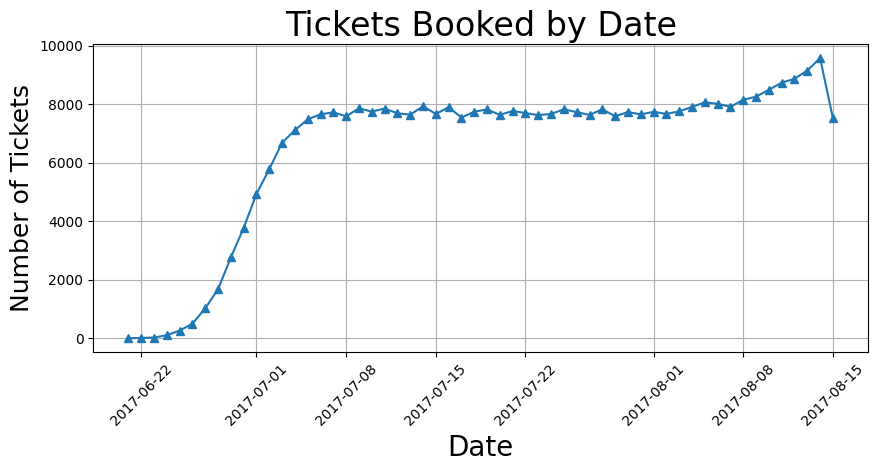

In [26]:
plt.figure(figsize= (10,4))
plt.plot(a['date'], a['count'], marker = '^')
plt.title('Tickets Booked by Date', fontsize = 24)
plt.xlabel('Date', fontsize = 20)
plt.ylabel('Number of Tickets', fontsize = 18)
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

In [27]:
bookings['book_date'] = (
    pd.to_datetime(bookings['book_date']))
bookings['date'] = bookings['book_date'].dt.date
bookings

,book_ref,book_date,total_amount,date
0,00000F,2017-07-05 03:12:00+03:00,265700,2017-07-05
1,000012,2017-07-14 09:02:00+03:00,37900,2017-07-14
2,000068,2017-08-15 14:27:00+03:00,18100,2017-08-15
3,000181,2017-08-10 13:28:00+03:00,131800,2017-08-10
4,0002D8,2017-08-07 21:40:00+03:00,23600,2017-08-07
...,...,...,...,...
262783,FFFEF3,2017-07-17 07:23:00+03:00,56000,2017-07-17
262784,FFFF2C,2017-08-08 05:55:00+03:00,10800,2017-08-08
262785,FFFF43,2017-07-20 20:42:00+03:00,78500,2017-07-20
262786,FFFFA8,2017-08-08 04:45:00+03:00,28800,2017-08-08


In [28]:
b = bookings.groupby('date')['total_amount'].sum().reset_index(name = 'total')
b.head()

,date,total
0,2017-06-21,441900
1,2017-06-22,775300
2,2017-06-23,1822000
3,2017-06-24,5977000
4,2017-06-25,15305400


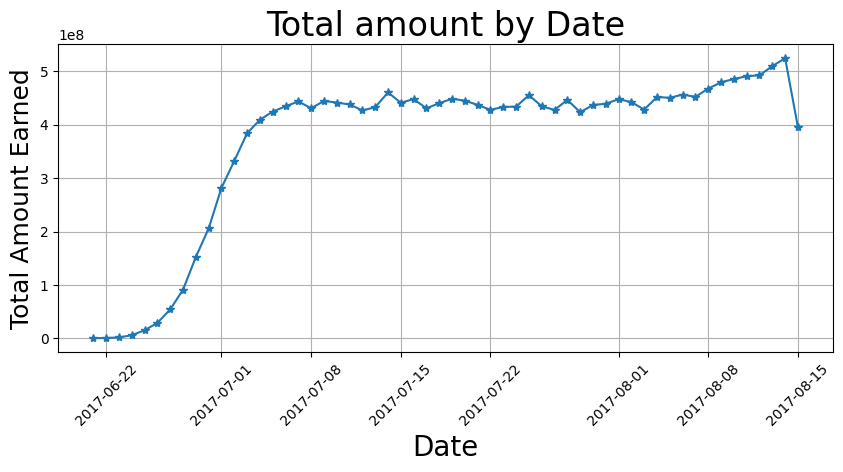

In [29]:
plt.figure(figsize= (10,4))
plt.plot(b['date'], b['total'], marker = '*')
plt.title('Total amount by Date', fontsize = 24)
plt.xlabel('Date', fontsize = 20)
plt.ylabel('Total Amount Earned', fontsize = 18)
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

#### 3.Calculate the average charges for each aircraft with different fare conditions.

In [30]:
charges = pd.read_sql_query("""select * from ticket_flights join
    flights on ticket_flights.flight_id = flights.flight_id """, connection)
charges

,ticket_no,flight_id,fare_conditions,amount,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,0005432159776,30625,Business,42100,30625,PG0013,2017-07-16 18:15:00+03,2017-07-16 20:00:00+03,AER,SVO,Arrived,773,2017-07-16 18:18:00+03,2017-07-16 20:04:00+03
1,0005435212351,30625,Business,42100,30625,PG0013,2017-07-16 18:15:00+03,2017-07-16 20:00:00+03,AER,SVO,Arrived,773,2017-07-16 18:18:00+03,2017-07-16 20:04:00+03
2,0005435212386,30625,Business,42100,30625,PG0013,2017-07-16 18:15:00+03,2017-07-16 20:00:00+03,AER,SVO,Arrived,773,2017-07-16 18:18:00+03,2017-07-16 20:04:00+03
3,0005435212381,30625,Business,42100,30625,PG0013,2017-07-16 18:15:00+03,2017-07-16 20:00:00+03,AER,SVO,Arrived,773,2017-07-16 18:18:00+03,2017-07-16 20:04:00+03
4,0005432211370,30625,Business,42100,30625,PG0013,2017-07-16 18:15:00+03,2017-07-16 20:00:00+03,AER,SVO,Arrived,773,2017-07-16 18:18:00+03,2017-07-16 20:04:00+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045721,0005435097522,32094,Economy,5200,32094,PG0708,2017-09-14 17:15:00+03,2017-09-14 18:00:00+03,SGC,OVS,Scheduled,733,\N,\N
1045722,0005435097521,32094,Economy,5200,32094,PG0708,2017-09-14 17:15:00+03,2017-09-14 18:00:00+03,SGC,OVS,Scheduled,733,\N,\N
1045723,0005435104384,32094,Economy,5200,32094,PG0708,2017-09-14 17:15:00+03,2017-09-14 18:00:00+03,SGC,OVS,Scheduled,733,\N,\N
1045724,0005435104352,32094,Economy,5200,32094,PG0708,2017-09-14 17:15:00+03,2017-09-14 18:00:00+03,SGC,OVS,Scheduled,733,\N,\N


In [31]:
avg_charges = (charges.groupby(['aircraft_code', 'fare_conditions'])['amount']
        .mean().reset_index(name = 'avg_amount'))
avg_charges

,aircraft_code,fare_conditions,avg_amount
0,319,Business,113550.557703
1,319,Economy,38311.402347
2,321,Business,34435.662664
3,321,Economy,11534.974764
4,733,Business,41865.626175
5,733,Economy,13985.152000
6,763,Business,82839.842866
7,763,Economy,27594.721829
8,773,Business,57779.909435
9,773,Comfort,32740.552889


Text(0, 0.5, 'Average Charges')

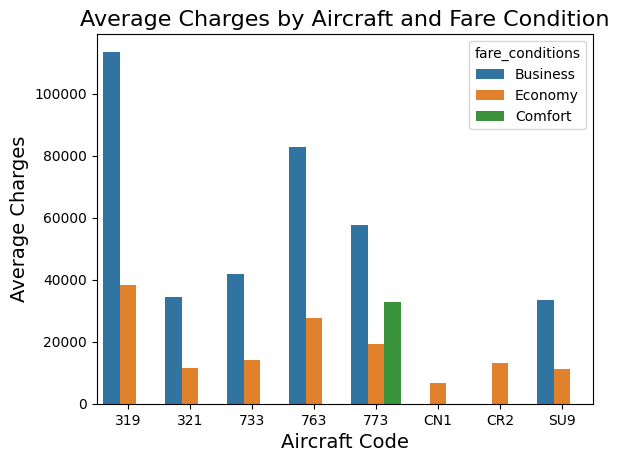

In [48]:
sns.barplot(data = avg_charges, x = 'aircraft_code', y = 'avg_amount', hue = 'fare_conditions' )
plt.title('Average Charges by Aircraft and Fare Condition', fontsize = 16)
plt.xlabel('Aircraft Code', fontsize = 14)
plt.ylabel('Average Charges', fontsize = 14)


#### The basic analysis of data provides insights into the number of planes with more than 100 seats, how the number of tickets booked and total amount earned changed over time, and the average fare for each aircraft with different fare conditions.

- These findings will be useful in developing strategies to increase occupancy rates and optimize pricing for each aircraft.

- Table 1 shows the aircraft with more than 100 seats and the actual count of the seats.

```
    aircraft_code	num_of_seats
0	 319        	116
1	 320	      	140
2	 321	      	170
3	 733	      	130
4	 763	      	222
5	 773	      	402
```

### Analyzing Occupency Rate
- 1. #### For each aircraft calculate the total revenue per year and the average revenue per ticket

In [33]:
pd.read_sql_query(""" select aircraft_code, ticket_count, total_revenue,
    total_revenue/ticket_count as avg_revenue_per_ticket from

    (select aircraft_code, count(*) as ticket_count ,
    sum(amount) as total_revenue from ticket_flights join flights
    on ticket_flights.flight_id = flights.flight_id group by aircraft_code) as t""",
                     connection)

,aircraft_code,ticket_count,total_revenue,avg_revenue_per_ticket
0,319,52853,2706163100,51201
1,321,107129,1638164100,15291
2,733,86102,1426552100,16568
3,763,124774,4371277100,35033
4,773,144376,3431205500,23765
5,CN1,14672,96373800,6568
6,CR2,150122,1982760500,13207
7,SU9,365698,5114484700,13985


- #### 2. Calculate the average occupancy per aircraft

In [34]:
t1 = pd.read_sql_query("""select aircraft_code, flights.flight_id, count(*) as seats_count
    from boarding_passes join flights on
    boarding_passes.flight_id = flights.flight_id
    group by aircraft_code, flights.flight_id""", connection)
t1

,aircraft_code,flight_id,seats_count
0,319,1162,51
1,319,1166,54
2,319,1167,57
3,319,1168,60
4,319,1170,58
...,...,...,...
11513,SU9,32925,12
11514,SU9,32928,25
11515,SU9,32931,12
11516,SU9,32933,16


In [35]:
t2 = pd.read_sql_query("""select aircraft_code, count(*) as total_seats from seats
    group by aircraft_code""", connection)
t2

,aircraft_code,total_seats
0,319,116
1,320,140
2,321,170
3,733,130
4,763,222
5,773,402
6,CN1,12
7,CR2,50
8,SU9,97


In [36]:
avg_occupancy = pd.merge(t1, t2, on = 'aircraft_code')
avg_occupancy['occupancy_rate'] = avg_occupancy['seats_count']/avg_occupancy['total_seats']
avg_occupancy

,aircraft_code,flight_id,seats_count,total_seats,occupancy_rate
0,319,1162,51,116,0.439655
1,319,1166,54,116,0.465517
2,319,1167,57,116,0.491379
3,319,1168,60,116,0.517241
4,319,1170,58,116,0.500000
...,...,...,...,...,...
11513,SU9,32925,12,97,0.123711
11514,SU9,32928,25,97,0.257732
11515,SU9,32931,12,97,0.123711
11516,SU9,32933,16,97,0.164948


In [37]:
final_report = avg_occupancy.groupby('aircraft_code').agg(
        booked_seats = ('seats_count','mean'),
        toal_plane_capacity = ('total_seats','mean'),
        avg_occupancy_rate = ('occupancy_rate', 'mean')
)
final_report['avg_occupancy_rate'] = (final_report['avg_occupancy_rate']*100).round(2)
final_report

,booked_seats,toal_plane_capacity,avg_occupancy_rate
aircraft_code,,,
319,53.583181,116.0,46.19
321,88.809231,170.0,52.24
733,80.255462,130.0,61.73
763,113.937294,222.0,51.32
773,264.925806,402.0,65.90
CN1,6.004431,12.0,50.04
CR2,21.482847,50.0,42.97
SU9,56.812113,97.0,58.57


- ### 3.Calculate by how much the total annual turnover could increase by giving all aircraft a 10% higher occupancy rate.

In [38]:
final_report['inc_occupancy_rate'] = (final_report['avg_occupancy_rate'] +
                final_report['avg_occupancy_rate']*0.1).round(2)
final_report

,booked_seats,toal_plane_capacity,avg_occupancy_rate,inc_occupancy_rate
aircraft_code,,,,
319,53.583181,116.0,46.19,50.81
321,88.809231,170.0,52.24,57.46
733,80.255462,130.0,61.73,67.90
763,113.937294,222.0,51.32,56.45
773,264.925806,402.0,65.90,72.49
CN1,6.004431,12.0,50.04,55.04
CR2,21.482847,50.0,42.97,47.27
SU9,56.812113,97.0,58.57,64.43


In [39]:
total_revenue = pd.read_sql_query("""select aircraft_code, sum(amount) as total_revenue
    from ticket_flights join flights on
    ticket_flights.flight_id = flights.flight_id group by aircraft_code""", connection)
total_revenue.set_index('aircraft_code', inplace= True)
total_revenue

,total_revenue
aircraft_code,
319,2706163100
321,1638164100
733,1426552100
763,4371277100
773,3431205500
CN1,96373800
CR2,1982760500
SU9,5114484700


In [40]:
analysis_df = pd.merge(final_report, total_revenue, on = 'aircraft_code')
analysis_df['inc_total_annual_turnover'] = ((analysis_df['total_revenue']/
            analysis_df['avg_occupancy_rate'])*analysis_df['inc_occupancy_rate'])
analysis_df

,booked_seats,toal_plane_capacity,avg_occupancy_rate,inc_occupancy_rate,total_revenue,inc_total_annual_turnover
aircraft_code,,,,,,
319,53.583181,116.0,46.19,50.81,2706163100,2.976838e+09
321,88.809231,170.0,52.24,57.46,1638164100,1.801855e+09
733,80.255462,130.0,61.73,67.90,1426552100,1.569138e+09
763,113.937294,222.0,51.32,56.45,4371277100,4.808234e+09
773,264.925806,402.0,65.90,72.49,3431205500,3.774326e+09
CN1,6.004431,12.0,50.04,55.04,96373800,1.060035e+08
CR2,21.482847,50.0,42.97,47.27,1982760500,2.181175e+09
SU9,56.812113,97.0,58.57,64.43,5114484700,5.626195e+09


In [41]:
analysis_df['revenue_growth'] = analysis_df['inc_total_annual_turnover'] - analysis_df['total_revenue']

analysis_df['revenue_growth'] = analysis_df['revenue_growth'].astype('int64')

analysis_df

,booked_seats,toal_plane_capacity,avg_occupancy_rate,inc_occupancy_rate,total_revenue,inc_total_annual_turnover,revenue_growth
aircraft_code,,,,,,,
319,53.583181,116.0,46.19,50.81,2706163100,2.976838e+09,270674897
321,88.809231,170.0,52.24,57.46,1638164100,1.801855e+09,163690976
733,80.255462,130.0,61.73,67.90,1426552100,1.569138e+09,142585881
763,113.937294,222.0,51.32,56.45,4371277100,4.808234e+09,436957356
773,264.925806,402.0,65.90,72.49,3431205500,3.774326e+09,343120549
CN1,6.004431,12.0,50.04,55.04,96373800,1.060035e+08,9629676
CR2,21.482847,50.0,42.97,47.27,1982760500,2.181175e+09,198414478
SU9,56.812113,97.0,58.57,64.43,5114484700,5.626195e+09,511710437


In [42]:
analysis_df['inc_total_annual_turnover'] = analysis_df['inc_total_annual_turnover'].astype('int64')
analysis_df = analysis_df.sort_values(by='revenue_growth', ascending=False)

In [43]:
analysis_df

,booked_seats,toal_plane_capacity,avg_occupancy_rate,inc_occupancy_rate,total_revenue,inc_total_annual_turnover,revenue_growth
aircraft_code,,,,,,,
SU9,56.812113,97.0,58.57,64.43,5114484700,5626195137,511710437
763,113.937294,222.0,51.32,56.45,4371277100,4808234456,436957356
773,264.925806,402.0,65.90,72.49,3431205500,3774326049,343120549
319,53.583181,116.0,46.19,50.81,2706163100,2976837997,270674897
CR2,21.482847,50.0,42.97,47.27,1982760500,2181174978,198414478
321,88.809231,170.0,52.24,57.46,1638164100,1801855076,163690976
733,80.255462,130.0,61.73,67.90,1426552100,1569137981,142585881
CN1,6.004431,12.0,50.04,55.04,96373800,106003476,9629676


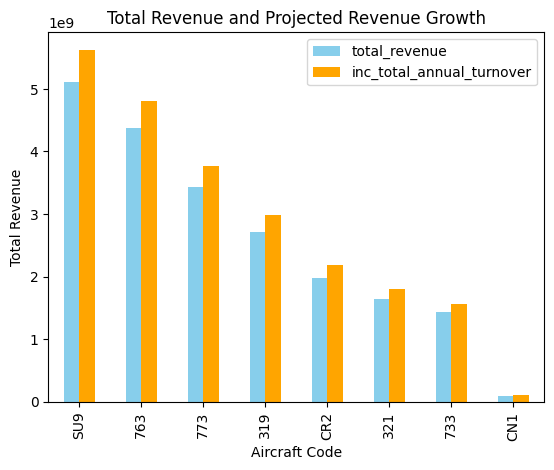

In [50]:
analysis_df[['total_revenue', 'inc_total_annual_turnover']].plot(kind='bar', color=['skyblue', 'orange'])
plt.xlabel('Aircraft Code')
plt.ylabel('Total Revenue')
plt.title('Total Revenue and Projected Revenue Growth')
plt.show()

### 1. Business Problem

The airline industry faces significant challenges including strict regulations, rising flight taxes, increasing fuel prices, and a tight labor market, all contributing to squeezed profit margins. The airline's core challenge is to shift from merely operating flights to maximizing the efficiency and profitability of every journey.

### 2. Project Objectives

To counter these pressures, the project aims to leverage data for enhanced profitability through specific objectives:

*   **Increase Occupancy Rate**: Identify and target underperforming flights to fill more seats, directly boosting profit per journey.
*   **Optimize Pricing Strategy**: Develop dynamic pricing models that respond to market conditions and customer preferences.
*   **Enhance Customer Experience**: Improve the entire customer journey to foster loyalty and competitive differentiation.
*   **Evaluate 'What-If' Impact**: Quantify the potential increase in annual turnover by boosting the occupancy rate by 10% across the fleet.

### 3. Data Exploration & Validation

All relevant tables from the `travel.sqlite` database were successfully loaded into pandas DataFrames, including `aircrafts_data`, `airports_data`, `boarding_passes`, `bookings`, `flights`, `seats`, `ticket_flights`, and `tickets`. A thorough data validation step confirmed the absence of missing values across all tables, ensuring data quality for subsequent analysis.

### 4. Basic Analysis Findings

*   **Planes with More than 100 Seats**: Six aircraft models possess a seating capacity exceeding 100:
    *   `319`: 116 seats
    *   `320`: 140 seats
    *   `321`: 170 seats
    *   `733`: 130 seats
    *   `763`: 222 seats
    *   `773`: 402 seats
*   **Temporal Trends in Bookings and Revenue**: Ticket bookings and total revenue exhibited similar trends between late June and late August 2017. Both showed a significant increase peaking around mid-July, followed by fluctuations and a gradual decline, highlighting their strong correlation.
*   **Average Charges by Aircraft and Fare Condition**: Average fares varied significantly by aircraft and fare class:
    *   **Business Class** consistently commanded the highest fares across all applicable aircraft (e.g., `319`, `763`, `773`, `SU9`).
    *   **Economy Class** remained the most affordable option.
    *   **Comfort Class** was exclusively offered on the `773` aircraft, with fares positioned between Business and Economy.
    *   The `319` aircraft recorded the highest average Business class fare (113,550.56), while `CN1` had the lowest average Economy fare (6,568.55).

### 5. Occupancy Rate Analysis & Strategic Insights

*   **Revenue and Average Revenue Per Ticket**: The `SU9` (Sukhoi Superjet) aircraft stands out as the fleet's 'workhorse,' generating the highest total revenue (5,114,484,700) and ticket count. Despite its high volume, its average ticket price (13,985) is comparatively low. This presents a significant opportunity to increase turnover by focusing on occupancy improvements rather than price hikes. The `319` aircraft, conversely, despite fewer total tickets, boasts a higher average revenue per ticket (51,201), indicating higher-value bookings.
*   **Average Occupancy Per Aircraft**: The average occupancy rates were calculated for each aircraft type:
    *   `SU9`: 58.57%
    *   `763`: 51.32%
    *   `773`: 65.90%
    *   `319`: 46.19%
    *   `CR2`: 42.97%
    *   `321`: 52.24%
    *   `733`: 61.73%
    *   `CN1`: 50.04%
    
The `CN1` aircraft, with low revenue and only Economy class offerings, is identified as a 'laggard.' Further investigation is needed to determine if its underperformance is due to poor facilities or if a complete pricing overhaul is required.
*   **Quantifying the 10% Occupancy Goal**: The analysis meticulously calculated the potential revenue growth if each aircraft were to achieve a 10% higher occupancy rate. This '10% goal' serves as a concrete target for marketing and operations to mitigate rising operational costs.
    *   The `analysis_df` clearly shows the baseline total revenue, the projected increase in total annual turnover, and the resultant revenue growth for each aircraft.
    *   The `SU9` aircraft demonstrated the highest potential revenue growth (511,710,437) with a 10% increase in occupancy, followed by `763` (436,957,356) and `773` (343,120,549).
    *   A comparative bar chart visually highlights these potential gains, emphasizing the substantial impact of improved occupancy across the fleet.

In conclusion, the analysis provides actionable insights into aircraft performance, revenue trends, and the significant financial benefits of even a modest increase in occupancy rates, particularly for high-volume aircraft like the `SU9`.